In [8]:
import os
import time
import random
import warnings
from datetime import date
import gc

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects


from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
SEED=42

In [9]:
pl.read_parquet("/home/adamp/Projects/SME-portal/data/extracted/prohlidky_vozidel_stk_a_sme/parquet")

CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,Prohlidka_Ukonceni,AdministrativniOprava_CisloProtokolu,AdministrativniOprava_DatumProhlidky,Vozidlo_Vin,Vozidlo_Druh,Vozidlo_Kategorie,Vozidlo_Provedeni,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Registrace_DatumPrvni,Registrace_Stat,Registrace_CisloDokladu,Emise_CisloProtokolu,Emise_DatumProhlidky,Emise_StaniceCislo,Emise_Zahajeni,Emise_Ukonceni,Emise_OdpovednaOsoba,Emise_ZakladniPalivo,Emise_AlternativniPalivo,Emise_EmisniSystem,Emise_VyrobceMotoru,Emise_CisloMotoru,Vysledek_Odometr,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C
str,date,str,str,i32,i32,str,str,str,datetime[μs],datetime[μs],str,date,str,str,str,str,str,str,str,datetime[μs],str,str,str,datetime[μs],i32,datetime[μs],datetime[μs],i32,str,str,str,str,str,i32,str,date,bool,i8,bool,bool,bool,list[str],list[str],list[str]
"""CZ-460914-26-02-0001""",2026-02-01,"""Pravidelná""",null,37175,460914,"""Pardubický kraj""","""Polička""","""Oldřiš""",2026-02-01 08:19:41.120,2026-02-01 08:45:43.070,null,null,"""VF7N0RHYB73251158""","""OSOBNÍ AUTOMOBIL""","""M1""",null,"""CITROËN""","""XSARA 2.0HDI""","""RHY""",2002-02-01 00:00:00,"""Česká republika""","""UBI016618""","""CZ-460914-26-02-0001""",2026-02-01 08:45:43.070,460914,2026-02-01 08:21:09.157,2026-02-01 08:44:12.410,37175,"""Nafta""",null,"""Řízený bez OBD""",null,null,2530112,null,2028-02-01,null,1,false,false,false,null,null,null
"""CZ-520406-26-02-0002""",2026-02-01,"""Pravidelná""",null,16835,520406,"""Středočeský kraj""","""Kolín""","""Žabonosy""",2026-02-01 09:31:55.593,2026-02-01 09:44:58.100,null,null,"""WV2ZZZ7HZ7H143589""","""NÁKLADNÍ AUTOMOBIL""","""N1""",null,"""VOLKSWAGEN""","""TRANSPORTER""","""BNZ""",2007-06-21 00:00:00,"""Česká republika""","""UBL540604""","""CZ-520406-26-02-0002""",2026-02-01 09:44:58.100,520406,2026-02-01 09:32:11.203,2026-02-01 09:44:40.490,16835,"""Nafta""",null,"""Řízený s OBD""",null,null,312169,null,2028-02-01,null,1,false,false,false,null,null,null
"""CZ-520406-26-02-0003""",2026-02-01,"""Pravidelná""",null,16835,520406,"""Středočeský kraj""","""Kolín""","""Žabonosy""",2026-02-01 09:48:07.213,2026-02-01 09:58:26.620,null,null,"""WF0GXXGBBGBP37169""","""OSOBNÍ AUTOMOBIL""","""M1""",null,"""FORD""","""MONDEO""","""TXBA""",2012-02-07 00:00:00,"""Česká republika""","""UAJ544353""","""CZ-520406-26-02-0003""",2026-02-01 09:58:26.620,520406,2026-02-01 09:48:24.727,2026-02-01 09:58:07.440,16835,"""Nafta""",null,"""Řízený s OBD""",null,null,362116,null,2028-02-01,null,1,false,false,false,null,null,null
"""CZ-110904-26-02-0005""",2026-02-01,"""Pravidelná""",null,103081,110904,"""Hlavní město Praha""","""Hlavní město Praha""","""Praha""",2026-02-01 10:06:51.493,2026-02-01 10:17:33.570,null,null,"""TMBEA6NH6H4549288""","""OSOBNÍ AUTOMOBIL""","""M1""",null,"""ŠKODA""","""RAPID""","""CJZ""",2017-09-21 00:00:00,"""Česká republika""","""UAS888330""","""CZ-110904-26-02-0005""",2026-02-01 10:17:33.570,110904,2026-02-01 10:07:07.147,2026-02-01 10:17:02.493,103081,"""Benzín""",null,"""Řízený s OBD""",null,null,44723,null,2028-02-01,null,1,false,false,false,null,null,null
"""CZ-161101-26-02-0001""",2026-02-01,"""Pravidelná""",null,97187,161101,"""Pardubický kraj""","""Žamberk""","""Jablonné nad Orlicí""",2026-02-01 10:25:05.447,2026-02-01 10:36:41.650,null,null,"""XMCMNZ34A8F038902""","""OSOBNÍ AUTOMOBIL""","""M1""","""AB HATCHBACK""","""MITSUBISHI""","""COLT Z34AMNLHL6""","""135930""",2008-03-05 00:00:00,"""Česká republika""","""UBG049570""","""CZ-161101-26-02-0001""",2026-02-01 10:36:41.650,161101,2026-02-01 10:27:11.183,2026-02-01 10:35:23.607,97187,"""Benzín""",null,"""Řízený s OBD""",null,null,205439,null,2028-02-01,null,1,false,false,false,null,null,null
…,…,…,…

In [10]:
pl.read_parquet("/home/adamp/Projects/SME-portal/data/extracted/data_z_mericich_pristroju/parquet")


CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vozidlo_Vin,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Vozidlo_CisloMotoru,Vozidlo_Odometer,Vozidlo_RokVyroby,Vozidlo_DatumPrvniRegistrace,Vozidlo_Palivo,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotka,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Vysledek_TesnostPlynovehoZarizeni,Vysledek_Vyhovuje,PristiProhlidka,EmisniSystem,Obd_KomunikacniProtokol,Obd_Vin,Obd_PocetDtc,Obd_VzdalenostDtc,Obd_CasDtc,Obd_KontrolaMil,Obd_VypisDtc,Zavady,Obd_Readiness_Vysledek,Obd_Readiness_Zazeh_AC_Podporovano,Obd_Readiness_Zazeh_AC_Otestovano,Obd_Readiness_Zazeh_CAT-FUNC_Podporovano,Obd_Readiness_Zazeh_CAT-FUNC_Otestovano,Obd_Readiness_Zazeh_COMP_Podporovano,Obd_Readiness_Zazeh_COMP_Otestovano,Obd_Readiness_Zazeh_EGR-VVT_Podporovano,Obd_Readiness_Zazeh_EGR-VVT_Otestovano,Obd_Readiness_Zazeh_EVAP_Podporovano,Obd_Readiness_Zazeh_EVAP_Otestovano,Obd_Readiness_Zazeh_FUEL_Podporovano,Obd_Readiness_Zazeh_FUEL_Otestovano,Obd_Readiness_Zazeh_HCAT_Podporovano,Obd_Readiness_Zazeh_HCAT_Otestovano,Obd_Readiness_Zazeh_MISF_Podporovano,Obd_Readiness_Zazeh_MISF_Otestovano,Obd_Readiness_Zazeh_O2S-FUNC_Podporovano,Obd_Readiness_Zazeh_O2S-FUNC_Otestovano,Obd_Readiness_Zazeh_O2S-HEAT_Podporovano,Obd_Readiness_Zazeh_O2S-HEAT_Otestovano,Obd_Readiness_Zazeh_SAS_Podporovano,Obd_Readiness_Zazeh_SAS_Otestovano,Obd_Readiness_Vznet_AC_Podporovano,Obd_Readiness_Vznet_AC_Otestovano,Obd_Readiness_Vznet_BOOST_Podporovano,Obd_Readiness_Vznet_BOOST_Otestovano,Obd_Readiness_Vznet_COMP_Podporovano,Obd_Readiness_Vznet_COMP_Otestovano,Obd_Readiness_Vznet_DPF_Podporovano,Obd_Readiness_Vznet_DPF_Otestovano,Obd_Readiness_Vznet_EGR-VVT_Podporovano,Obd_Readiness_Vznet_EGR-VVT_Otestovano,Obd_Readiness_Vznet_EGS_Podporovano,Obd_Readiness_Vznet_EGS_Otestovano,Obd_Readiness_Vznet_FUEL_Podporovano,Obd_Readiness_Vznet_FUEL_Otestovano,Obd_Readiness_Vznet_MISF_Podporovano,Obd_Readiness_Vznet_MISF_Otestovano,Obd_Readiness_Vznet_NMHC_Podporovano,Obd_Readiness_Vznet_NMHC_Otestovano,Obd_Readiness_Vznet_NOX_Podporovano,Obd_Readiness_Vznet_NOX_Otestovano,Obd_Readiness_Vznet_RESERVE_Podporovano,Obd_Readiness_Vznet_RESERVE_Otestovano,Obd_Readiness_J1939_AC_Podporovano,Obd_Readiness_J1939_AC_Otestovano,Obd_Readiness_J1939_BOOST_Podporovano,Obd_Readiness_J1939_BOOST_Otestovano,Obd_Readiness_J1939_CAT-FUNC_Podporovano,Obd_Readiness_J1939_CAT-FUNC_Otestovano,Obd_Readiness_J1939_COLD_Podporovano,Obd_Readiness_J1939_COLD_Otestovano,Obd_Readiness_J1939_COMP_Podporovano,Obd_Readiness_J1939_COMP_Otestovano,Obd_Readiness_J1939_DPF_Podporovano,Obd_Readiness_J1939_DPF_Otestovano,Obd_Readiness_J1939_EGR-VVT_Podporovano,Obd_Readiness_J1939_EGR-VVT_Otestovano,Obd_Readiness_J1939_EGS-FUNC_Podporovano,Obd_Readiness_J1939_EGS-FUNC_Otestovano,Obd_Readiness_J1939_EGS-HEAT_Podporovano,Obd_Readiness_J1939_EGS-HEAT_Otestovano,Obd_Readiness_J1939_EVAP_Podporovano,Obd_Readiness_J1939_EVAP_Otestovano,Obd_Readiness_J1939_FUEL_Podporovano,Obd_Readiness_J1939_FUEL_Otestovano,Obd_Readiness_J1939_HCAT_Podporovano,Obd_Readiness_J1939_HCAT_Otestovano,Obd_Readiness_J1939_MISF_Podporovano,Obd_Readiness_J1939_MISF_Otestovano,Obd_Readiness_J1939_NM-HC_Podporovano,Obd_Readiness_J1939_NM-HC_Otestovano,Obd_Readiness_J1939_NOX_Podporovano,Obd_Readiness_J1939_NOX_Otestovano,Obd_Readiness_J1939_SAS_Podporovano,Obd_Readiness_J1939_SAS_Otestovano,Benzin_Palivo,Benzin_PocetVyusteni,Benzin_OtackyVolnobezne_CO_Max_Hodnota,Benzin_OtackyVolnobezne_CO_Max_RucniZadani,Benzin_OtackyVolnobezne_CO_Hodnota,Benzin_OtackyVolnobezne_CO_Vysledek,Benzin_OtackyVolnobezne_CO2_Hodnota,Benzin_OtackyVolnobezne_CO2_Vysledek,Benzin_OtackyVolnobezne_COCOOR_Hodnota,Benzin_OtackyVolnobezne_COCOOR_Vysledek,Benzin_OtackyVolnobezne_HC_Max_Hodnota,Benzin_OtackyVolnobezne_HC_Max_RucniZadani,Benzin_Otacky

In [11]:
lf_prohlidky = pl.scan_parquet("/home/adamp/Projects/SME-portal/data/extracted/prohlidky_vozidel_stk_a_sme/parquet")
lf_mereni = pl.scan_parquet("/home/adamp/Projects/SME-portal/data/extracted/data_z_mericich_pristroju/parquet")

In [ ]:
# lf_prohlidky.select(['CisloProtokolu', 'DatumProhlidky']).collect()

In [25]:
df_selected = lf_mereni.select(['CisloProtokolu', 'DatumProhlidky', 'Vysledek_Vyhovuje', 'StaniceCislo', 'Zahajeni', 'Ukonceni']).collect()

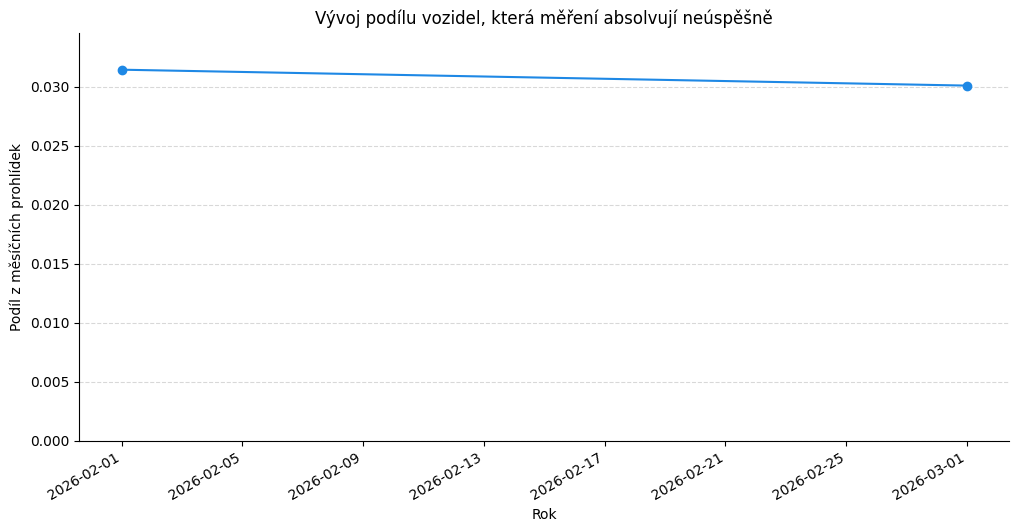

In [ ]:
time_series_monthly_expr(df_selected, 'DatumProhlidky', (1 - (pl.col('Vysledek_Vyhovuje') == True).fill_null(False).mean()), 'Vývoj podílu vozidel, která měření absolvují neúspěšně', 'Podíl z měsíčních prohlídek')#, 'kod/casove_rady/vyvoj_pruchodnosti.svg', decimals=2)

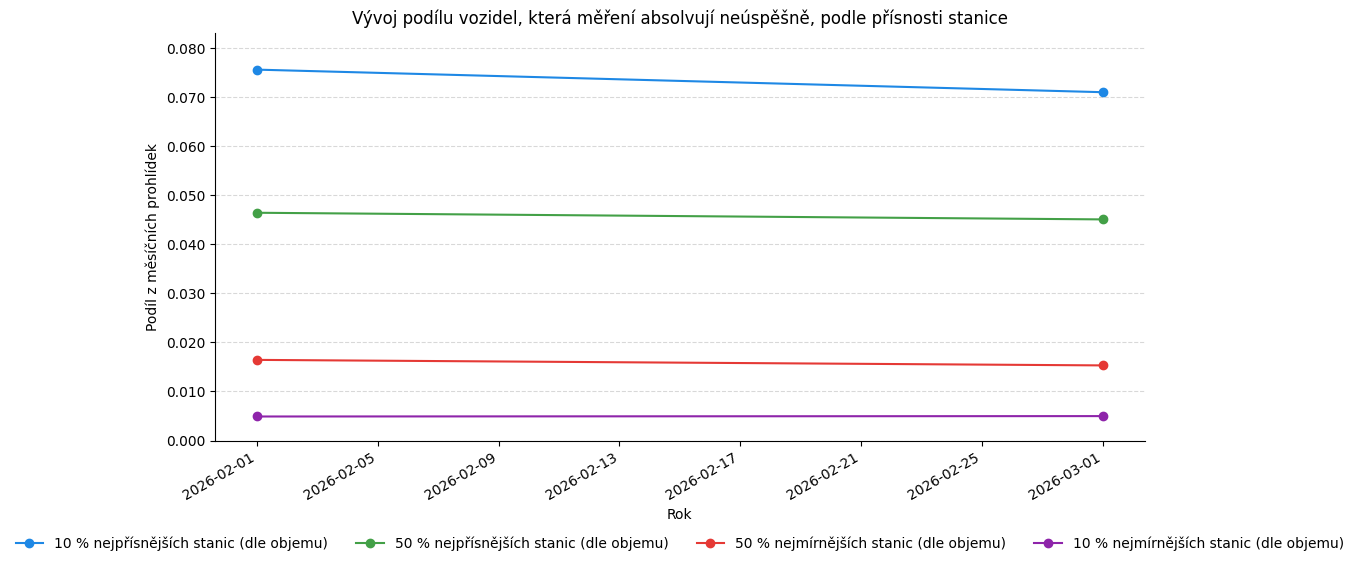

In [ ]:
# Agregace neúspěšnosti a objemu měření pro jednotlivé stanice
df_stations = df_selected.group_by("StaniceCislo").agg(
    celkem=pl.len(),
    nevyhovuje=pl.col("Vysledek_Vyhovuje").is_null().sum()
).with_columns(
    neuspesnost=pl.col("nevyhovuje") / pl.col("celkem")
)

# Výpočet limitů pro stanovení podílu na celkovém objemu dat
limit_10 = df_selected.height * 0.10
limit_50 = df_selected.height * 0.50

# Funkce pro výběr stanic naplňujících objemový limit podle míry neúspěšnosti
def get_stations(limit, desc_neuspesnost):
    return (
        df_stations.sort(["neuspesnost", "celkem"], descending=[desc_neuspesnost, True])
        .with_columns(cum_celkem=pl.col("celkem").cum_sum())
        .filter(pl.col("cum_celkem") <= limit)
        .get_column("StaniceCislo")
        .to_list()
    )

# Generování seznamů stanic pro nejhorší a nejlepší segmenty trhu
worst_10_stations = get_stations(limit_10, desc_neuspesnost=True)
best_10_stations = get_stations(limit_10, desc_neuspesnost=False)
worst_50_stations = get_stations(limit_50, desc_neuspesnost=True)
best_50_stations = get_stations(limit_50, desc_neuspesnost=False)

# Funkce pro tvorbu agregačního výrazu počítajícího podíl neúspěšných prohlídek
def create_expr(stations_list, alias_name):
    return (
        pl.col("Vysledek_Vyhovuje").filter(pl.col("StaniceCislo").is_in(stations_list)).is_null().sum() /
        pl.col("StaniceCislo").filter(pl.col("StaniceCislo").is_in(stations_list)).len()
    ).alias(alias_name)

# Sestavení finálních výrazů pro měsíční časové řady v grafu
exprs = [
    create_expr(worst_10_stations, "10 % nejpřísnějších stanic (dle objemu)"),
    create_expr(worst_50_stations, "50 % nejpřísnějších stanic (dle objemu)"),
    create_expr(best_50_stations, "50 % nejmírnějších stanic (dle objemu)"),
    create_expr(best_10_stations, "10 % nejmírnějších stanic (dle objemu)"),
]

time_series_monthly_expr(df_selected, 'DatumProhlidky', exprs, 'Vývoj podílu vozidel, která měření absolvují neúspěšně, podle přísnosti stanice', 'Podíl z měsíčních prohlídek')#, 'kod/casove_rady/vyvoj_pruchodnosti_podle_stanice.svg', decimals=2)

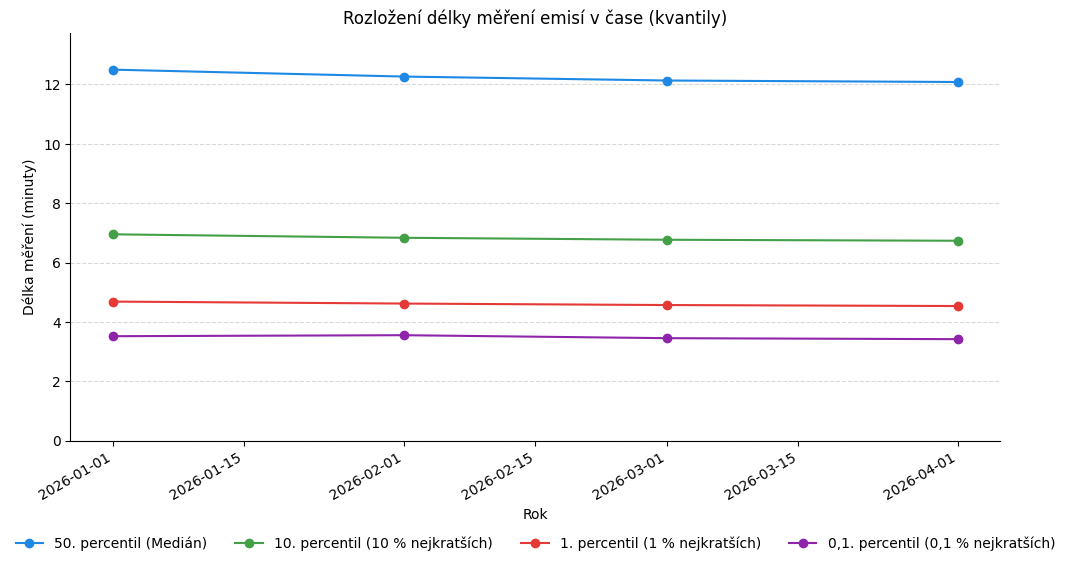

In [27]:
# Příprava dat: filtrace prázdných časů, zařazení do měsíce a výpočet délky v minutách
# Použití total_seconds() / 60 zajišťuje desetinnou přesnost na rozdíl od celočíselného total_minutes()
df_duration = df_selected.filter(
    pl.col("Zahajeni").is_not_null() & 
    pl.col("Ukonceni").is_not_null() &
    pl.col("Vysledek_Vyhovuje").is_not_null()
).with_columns(
    pl.col("Zahajeni").dt.truncate("1mo").alias("_ts_month"),
    ((pl.col("Ukonceni") - pl.col("Zahajeni")).dt.total_seconds() / 60.0).alias("delka_mereni_min")
)

# Volitelné, ale doporučené: odfiltrování zjevných datových chyb (např. záporný čas nebo měření nad 3 hodiny)
df_duration = df_duration.filter(
    (pl.col("delka_mereni_min") > 0) & 
    (pl.col("delka_mereni_min") < 180)
)

# Agregace délek všech měření do kvantilů v jednotlivých měsících
df_quantiles_duration = df_duration.group_by("_ts_month").agg([
    pl.col("delka_mereni_min").median().alias("50. percentil (Medián)"),
    pl.col("delka_mereni_min").quantile(0.10).alias("10. percentil (10 % nejkratších)"),
    pl.col("delka_mereni_min").quantile(0.01).alias("1. percentil (1 % nejkratších)"),
    pl.col("delka_mereni_min").quantile(0.001).alias("0,1. percentil (0,1 % nejkratších)"),
])

# Zavolání vizualizační funkce s hotovými kvantily
time_series_monthly_expr(
    df=df_quantiles_duration, 
    time_col="_ts_month", 
    exprs=None,                
    title="Rozložení délky měření emisí v čase (kvantily)", 
    y_title="Délka měření (minuty)",
    decimals=0,
    # save_path='kod/casove_rady/delka_prohlidky.svg'
)

In [44]:
uzsi_prohlidky = set(lf_prohlidky.select(['CisloProtokolu', 'Vozidlo_Kategorie', 'Emise_ZakladniPalivo', 'Emise_AlternativniPalivo']).filter(pl.col('Vozidlo_Kategorie') == 'M1', pl.col('Emise_ZakladniPalivo').is_in(['Benzín', 'Nafta']), pl.col('Emise_AlternativniPalivo').is_null()).select('CisloProtokolu').collect()['CisloProtokolu'].to_list())

In [69]:
required_benzin = [
    # Benzin Vždy (Volnoběžné)
    "Benzin_OtackyVolnobezne_CO_Hodnota",
    "Benzin_OtackyVolnobezne_CO_Max_Hodnota",
    "Benzin_OtackyVolnobezne_N_Hodnota",
    "Benzin_OtackyVolnobezne_N_Min_Hodnota",
    "Benzin_OtackyVolnobezne_N_Max_Hodnota",
    
    # Benzin Zvýšené
    "Benzin_OtackyZvysene_LAMBDA_Hodnota",
    "Benzin_OtackyZvysene_LAMBDA_Min_Hodnota",
    "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota",
    "Benzin_OtackyZvysene_CO_Hodnota",
    "Benzin_OtackyZvysene_CO_Max_Hodnota",
    "Benzin_OtackyZvysene_N_Hodnota",
    "Benzin_OtackyZvysene_N_Min_Hodnota",
    "Benzin_OtackyZvysene_N_Max_Hodnota"
]
required_nafta = [
    # Nafta Průměr
    "Nafta_MereniPrumer_CasAkcelerace_Hodnota",
    "Nafta_MereniPrumer_Kourivost_Hodnota",
    "Nafta_MereniPrumer_OtackyVolnobezne_Hodnota",
    "Nafta_MereniPrumer_OtackyPrebehove_Hodnota",
    
    # Nafta Limit Max
    "Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota",
    "Nafta_MereniVznetLimit_Kourivost_Max_Hodnota",
    "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota",
    "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota",
    
    # Nafta Limit Min
    "Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota",
    "Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota"
]
benzin_mask = pl.all_horizontal(pl.col(required_benzin).is_not_null())
nafta_mask = pl.all_horizontal(pl.col(required_nafta).is_not_null())

limits_bounds_benzin = [
    # (Název atributu limitu, Očekávané MIN limitu, Očekávané MAX limitu)
    ('Benzin_OtackyVolnobezne_CO_Max_Hodnota', 0.05, 5.0),
    ('Benzin_OtackyVolnobezne_N_Min_Hodnota', 300, 3000),
    ('Benzin_OtackyVolnobezne_N_Max_Hodnota', 300, 3000),
    ('Benzin_OtackyZvysene_CO_Max_Hodnota', 0.01, 1.0),
    ('Benzin_OtackyZvysene_LAMBDA_Min_Hodnota', 0.9, 1.00),
    ('Benzin_OtackyZvysene_LAMBDA_Max_Hodnota', 1.00, 1.1),
    ('Benzin_OtackyZvysene_N_Min_Hodnota', 1000, 10000),
    ('Benzin_OtackyZvysene_N_Max_Hodnota', 1000, 10000)
]

limits_bounds_nafta = [
    # (Název atributu limitu, Očekávané MIN limitu, Očekávané MAX limitu)
    ('Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota', 0.1, 10.0),
    ('Nafta_MereniVznetLimit_Kourivost_Max_Hodnota', 0.01, 3.0),
    ('Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota', 300, 3000),
    ('Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota', 300, 3000),
    ('Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota', 1000, 10000),
    ('Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota', 1000, 10000)
]

check_limits_integrity = [
    ("Benzin_OtackyVolnobezne_N_Min_Hodnota", "Benzin_OtackyVolnobezne_N_Max_Hodnota"),
    ("Benzin_OtackyZvysene_LAMBDA_Min_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota"),
    ("Benzin_OtackyZvysene_N_Min_Hodnota", "Benzin_OtackyZvysene_N_Max_Hodnota"),
    ("Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota"),
    ("Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota")
]

df_valid = lf_mereni.select(['CisloProtokolu', 'EmisniSystem', 'Vysledek_Vyhovuje', 'DatumProhlidky'] + required_benzin + required_nafta).filter(
    pl.col('EmisniSystem').cast(pl.String).str.contains('Rizeny'),
    pl.col('CisloProtokolu').is_in(uzsi_prohlidky), pl.any_horizontal(~(cs.numeric() < 0)),
    pl.col("Vysledek_Vyhovuje").is_not_null(),
    benzin_mask | nafta_mask,
    *[(pl.col(col).is_between(low, high) | nafta_mask) for col, low, high in limits_bounds_benzin],
    *[(pl.col(col).is_between(low, high) | benzin_mask) for col, low, high in limits_bounds_nafta],
    *[(pl.col(min_col) < pl.col(max_col)).fill_null(True) for min_col, max_col in check_limits_integrity],
).collect()

In [70]:
all_mappings = [
    ("Benzin_OtackyVolnobezne_CO_Hodnota", None, "Benzin_OtackyVolnobezne_CO_Max_Hodnota"),
    ("Benzin_OtackyVolnobezne_N_Hodnota", "Benzin_OtackyVolnobezne_N_Min_Hodnota", "Benzin_OtackyVolnobezne_N_Max_Hodnota"),
    ("Benzin_OtackyZvysene_LAMBDA_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Min_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota"),
    ("Benzin_OtackyZvysene_CO_Hodnota", None, "Benzin_OtackyZvysene_CO_Max_Hodnota"),
    ("Benzin_OtackyZvysene_N_Hodnota", "Benzin_OtackyZvysene_N_Min_Hodnota", "Benzin_OtackyZvysene_N_Max_Hodnota"),
    ("Nafta_MereniPrumer_CasAkcelerace_Hodnota", None, "Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota"),
    ("Nafta_MereniPrumer_Kourivost_Hodnota", None, "Nafta_MereniVznetLimit_Kourivost_Max_Hodnota"),
    ("Nafta_MereniPrumer_OtackyVolnobezne_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota"),
    ("Nafta_MereniPrumer_OtackyPrebehove_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota")
]

norm_exprs = [
    ((pl.col(val_col) - (pl.col(min_col) if min_col else pl.lit(0))) / 
     (pl.col(max_col) - (pl.col(min_col) if min_col else pl.lit(0)))
    ).alias(f"{val_col}_Norm")
    for val_col, min_col, max_col in all_mappings
]

df_valid = df_valid.with_columns(norm_exprs).drop(required_benzin + required_nafta)

df_benzin = df_valid.select(['DatumProhlidky'] + [f"{m[0]}_Norm" for m in all_mappings if m[0].startswith('Benzin')]).drop_nulls()
df_nafta = df_valid.select(['DatumProhlidky'] + [f"{m[0]}_Norm" for m in all_mappings if m[0].startswith('Nafta')]).drop_nulls()

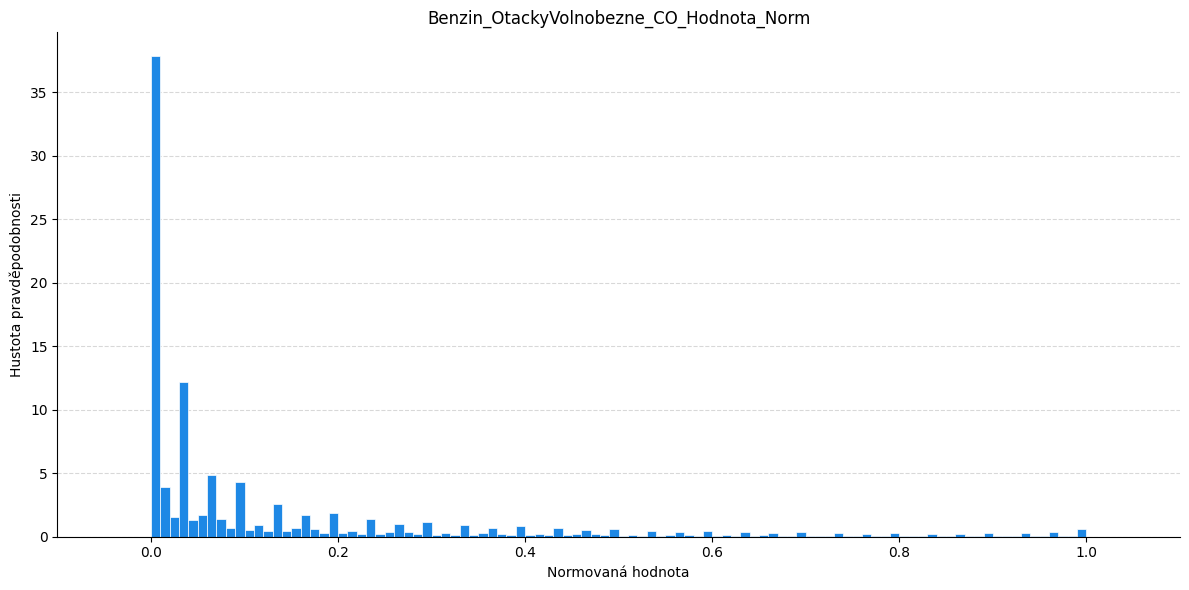

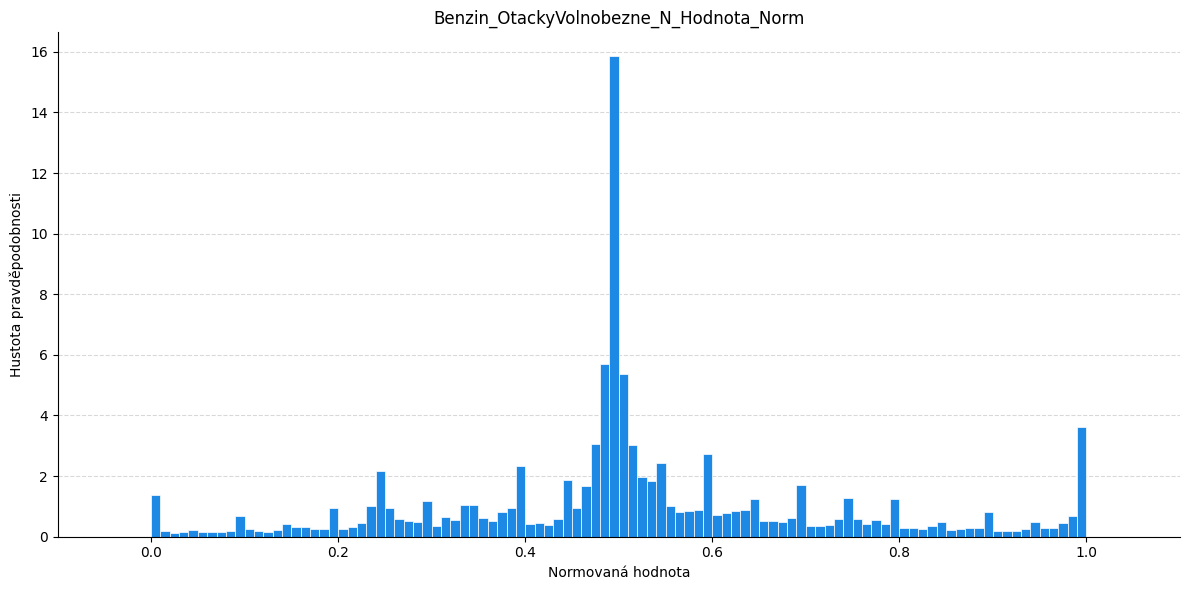

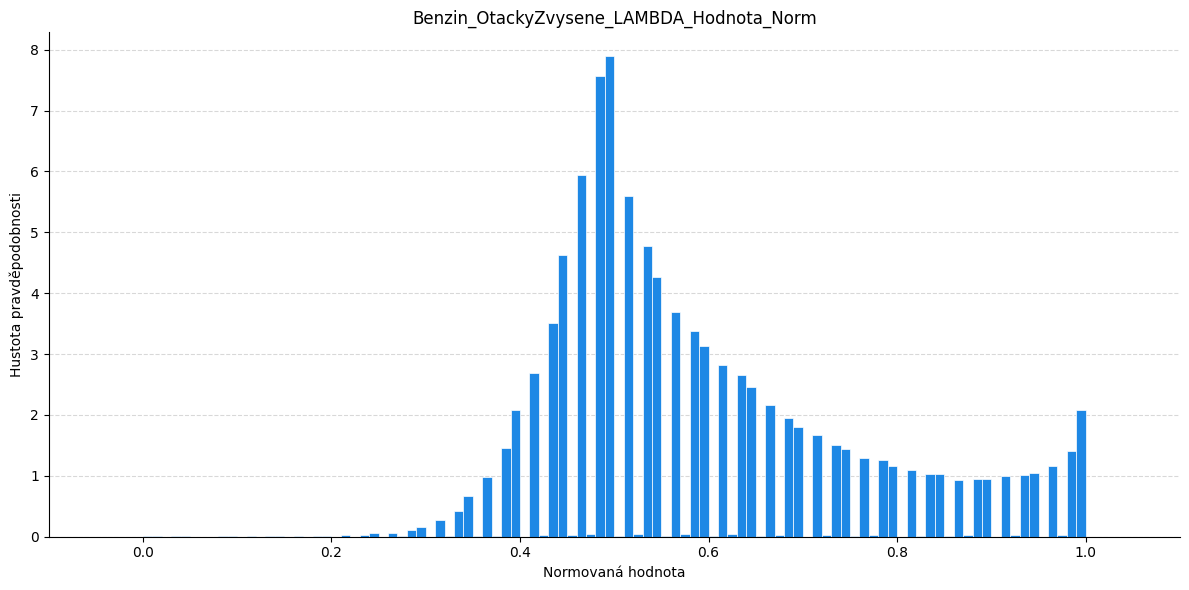

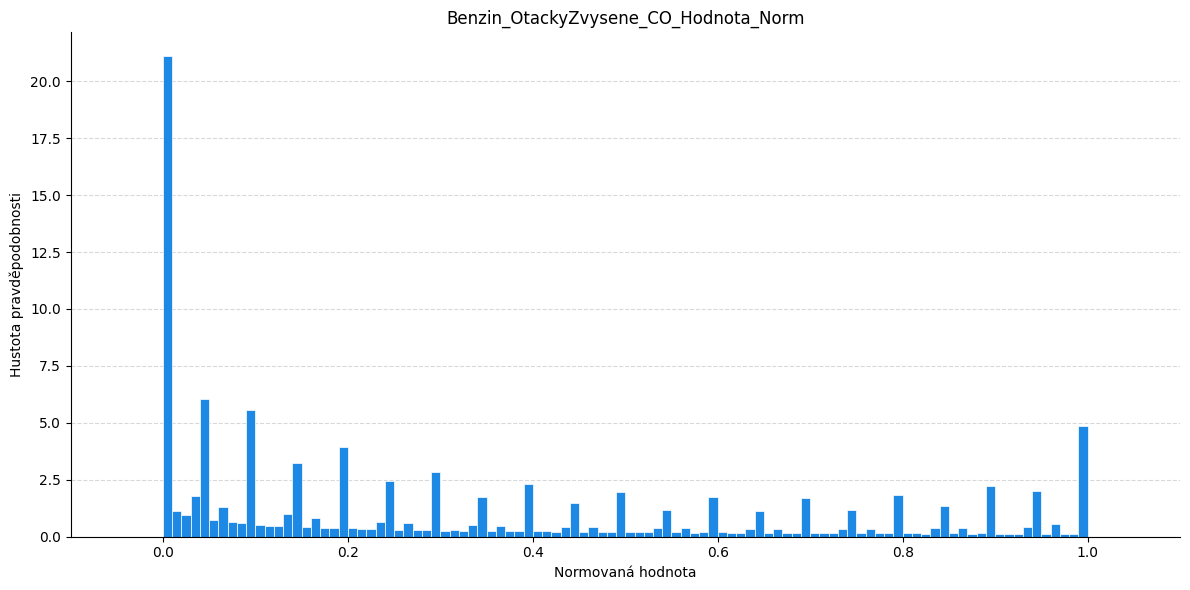

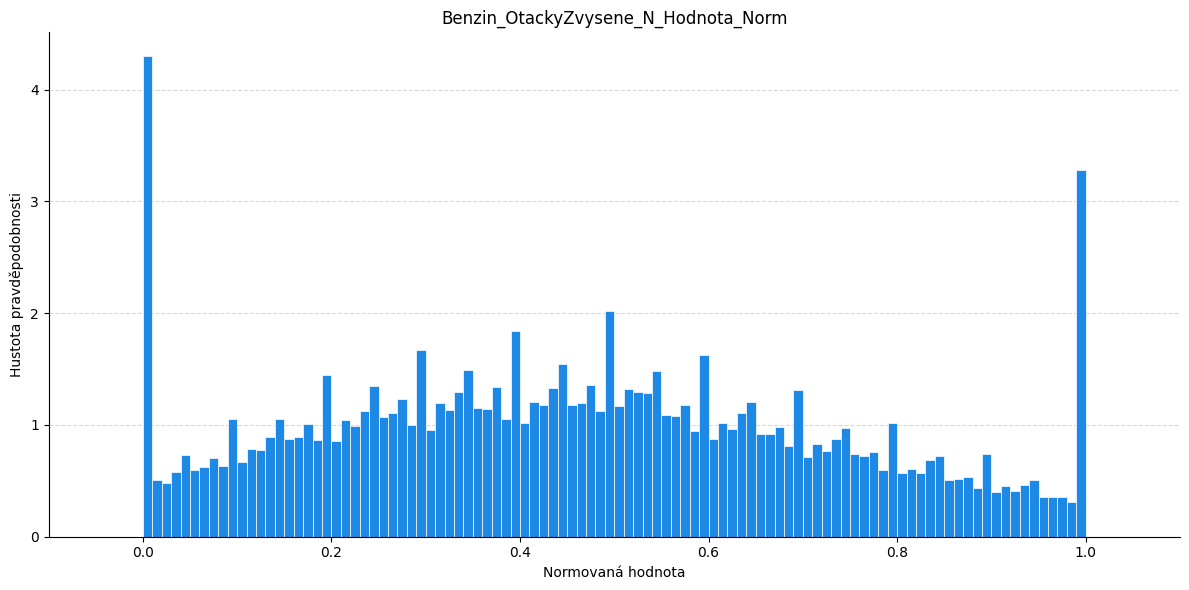

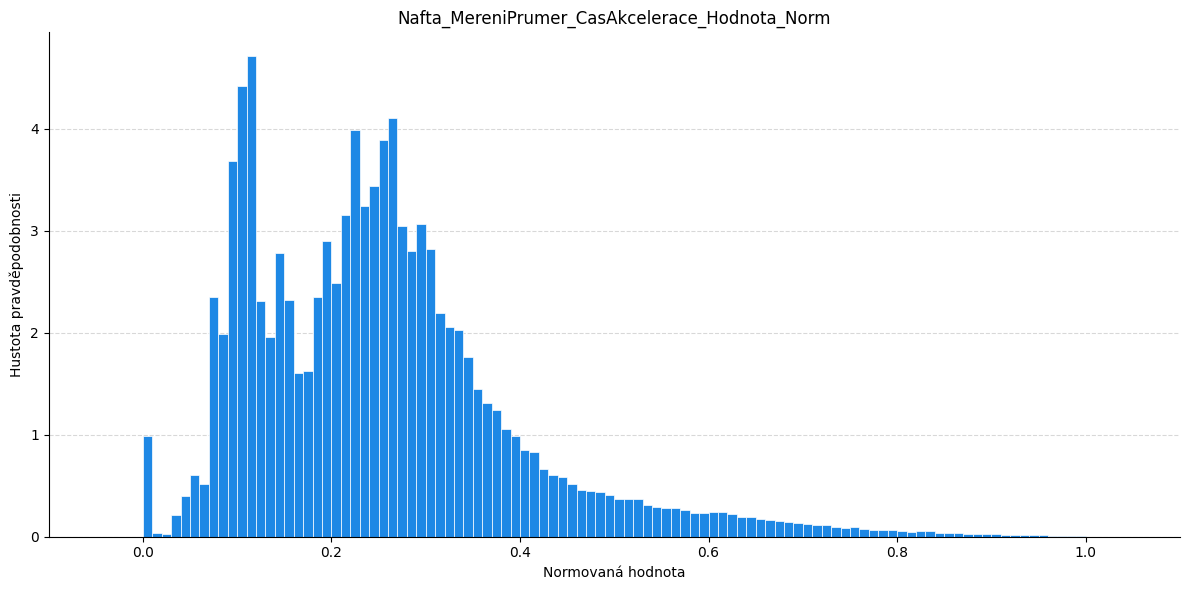

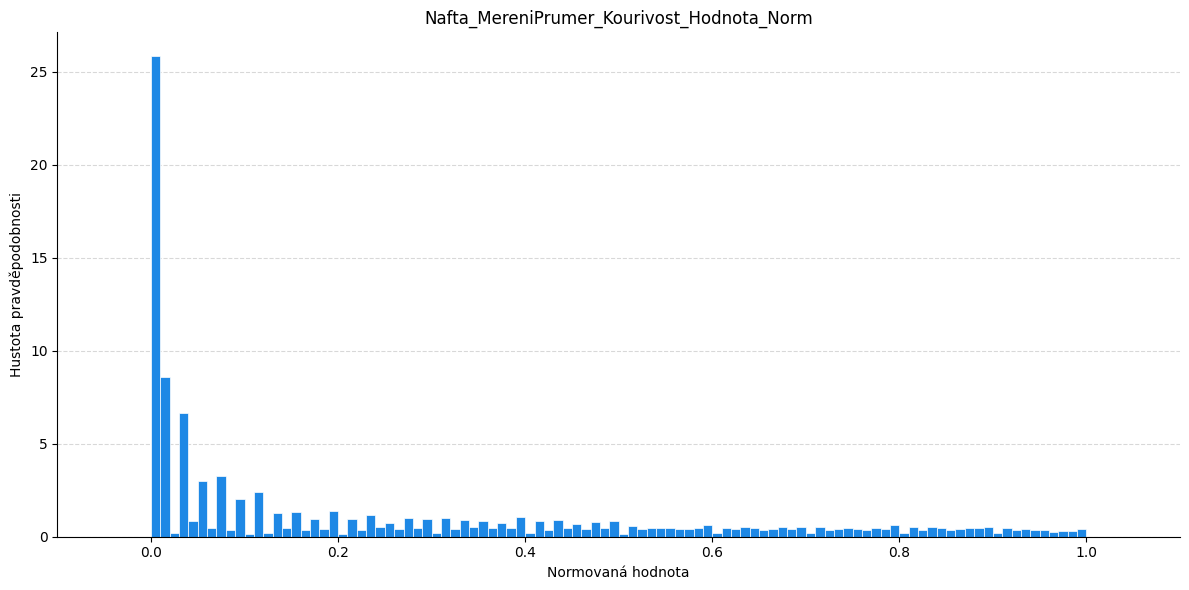

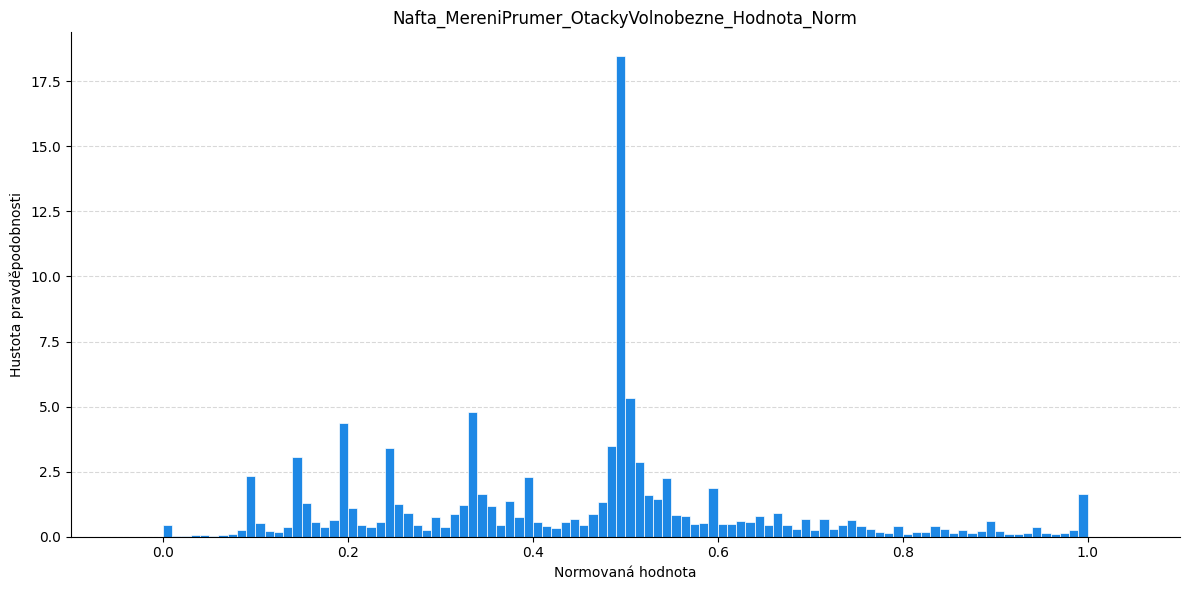

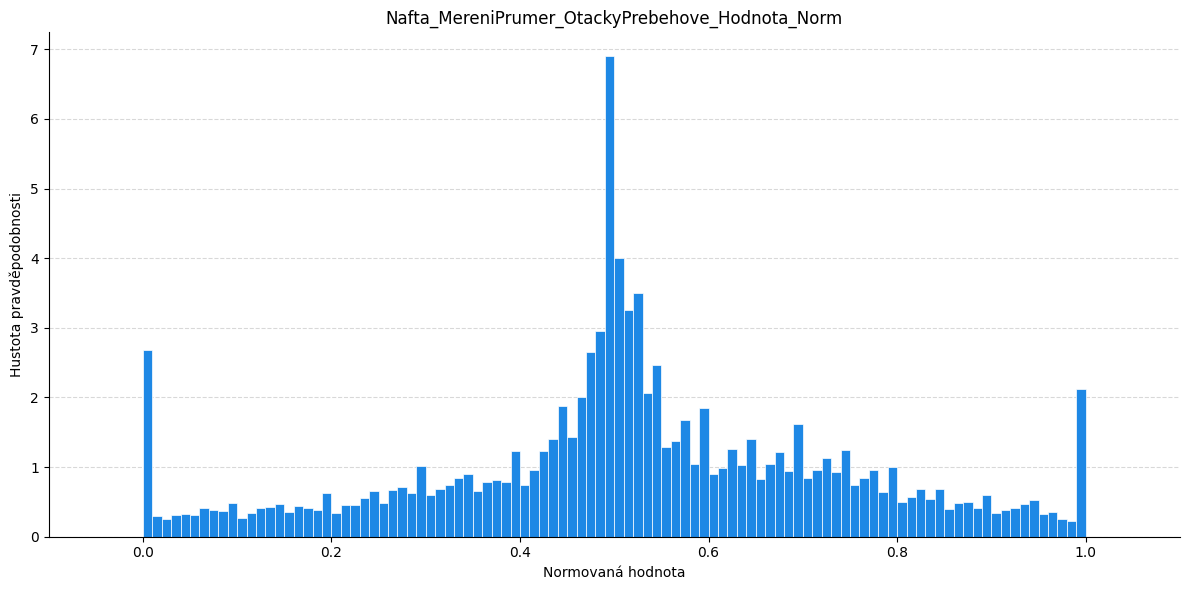

In [ ]:
def plot_norms(df):
    for col in df.columns:
        distribution_density_plot(df.filter(pl.col(col).is_between(-0.1, 1.1)), col, col, 'Normovaná hodnota', 100, (0, 1.00001))#, save_path=f'kod/explorace/mereni_grafy/rozdeleni_{col}.svg')
plot_norms(df_benzin.drop('DatumProhlidky'))
plot_norms(df_nafta.drop('DatumProhlidky'))

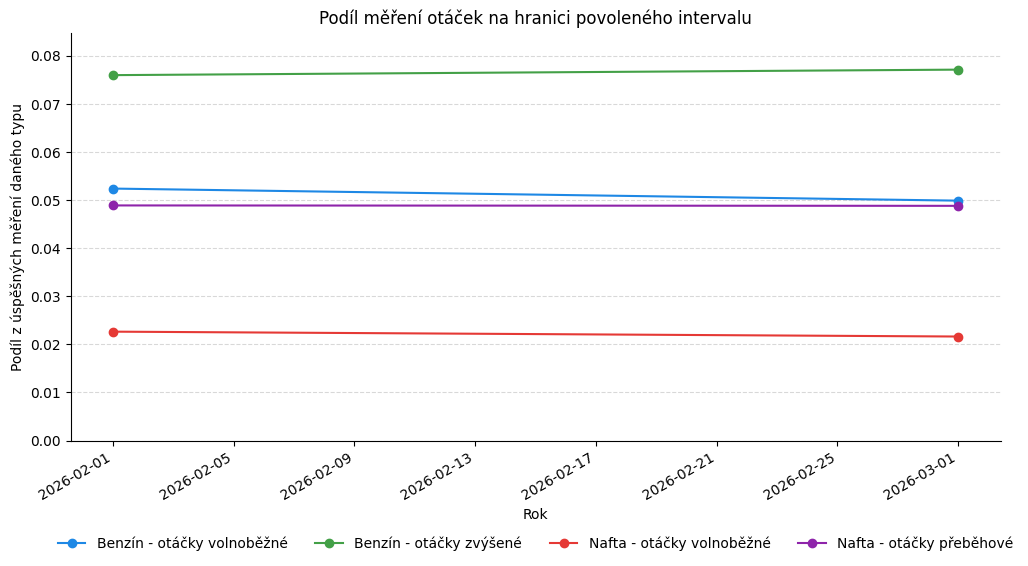

In [75]:
epsilon = 0.01

# Pomocná funkce pro tvorbu výrazu (aby se kód neopakoval)
def get_suspect_expr(col):
    clean_name = (
        col.replace('Benzin_OtackyVolnobezne_N_Hodnota_Norm', 'Benzín - otáčky volnoběžné')
           .replace('Benzin_OtackyZvysene_N_Hodnota_Norm' , 'Benzín - otáčky zvýšené')
           .replace('Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm', 'Nafta - otáčky volnoběžné')
           .replace('Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm', 'Nafta - otáčky přeběhové')
    )
    is_suspect = pl.col(col).is_between(-epsilon, epsilon) | pl.col(col).is_between(1 - epsilon, 1 + epsilon)
    return (is_suspect.fill_null(False).sum() / pl.col(col).is_not_null().sum()).alias(clean_name)

cols_otacky = [
    'Benzin_OtackyVolnobezne_N_Hodnota_Norm', 
    'Benzin_OtackyZvysene_N_Hodnota_Norm', 
    'Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm', 
    'Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm'
]
cols_otacky_exist = [c for c in cols_otacky if c in df_valid.columns]
exprs_otacky = [get_suspect_expr(c) for c in cols_otacky_exist]

time_series_monthly_expr(
    df=df_valid, 
    time_col="DatumProhlidky", 
    exprs=exprs_otacky,
    title="Podíl měření otáček na hranici povoleného intervalu",
    y_title="Podíl z úspěšných měření daného typu",
    decimals=2,
    # save_path='kod/casove_rady/mereni_krajni_hodnoty_otacky.svg'
)

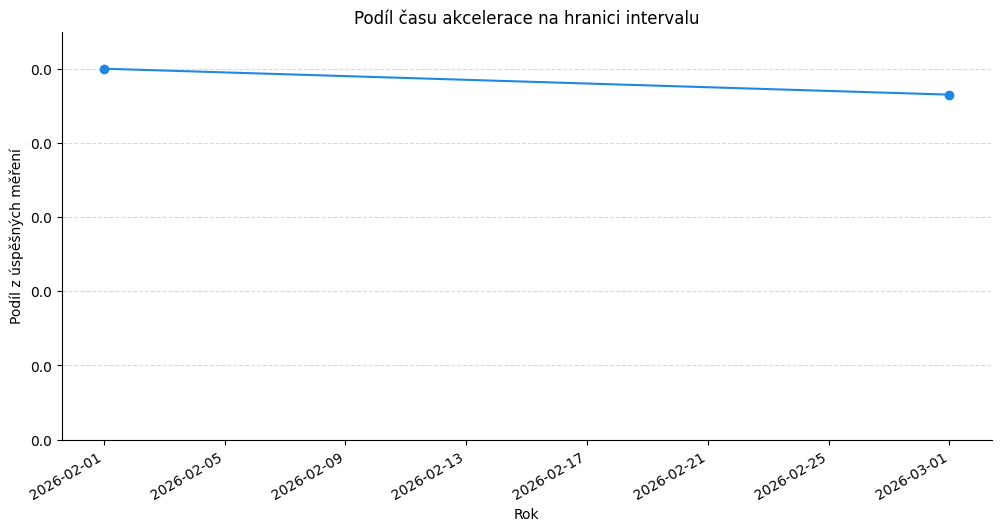

In [77]:
col_akcelerace = 'Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm'

if col_akcelerace in df_valid.columns:
    exprs_akcelerace = [get_suspect_expr(col_akcelerace)]
    
    time_series_monthly_expr(
        df=df_valid, 
        time_col="DatumProhlidky", 
        exprs=exprs_akcelerace,
        title="Podíl času akcelerace na hranici intervalu",
        y_title="Podíl z úspěšných měření",
        decimals=1,
        # save_path='kod/casove_rady/mereni_krajni_hodnoty_akcelerace.svg'
    )

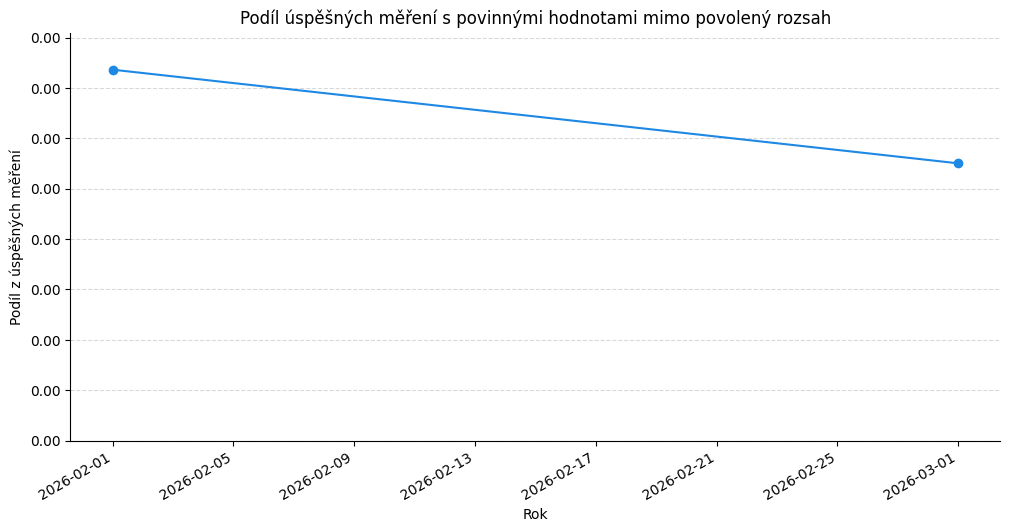

Bad pipe message: %s [b'"Google Chrome";v="147", "Not.A/Brand";v="8", "Chromium";']
Bad pipe message: %s [b'"147"\r\nsec-ch-ua-mobile: ?0\r\nsec-ch-ua-platform: "Windows"\r\nUpgrade-Insecure-Requests: 1\r\nUser-Agent: Mozilla/5.0 (Wi', b'ows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36\r\nAccept: text/']
Bad pipe message: %s [b'ml,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/s']
Bad pipe message: %s [b'ol: max-age=0\r\nsec-ch-ua: "Google Chrome";v="147", "Not.A/Brand";v="8", "Chromium";v="147"\r\nsec-ch-ua-mobile: ?0\r\ns']
Bad pipe message: %s [b'-ch-ua-platform: "Windows"\r\nUpgrade-Insecure-Requests: 1\r\nUser-Agent: Mozilla/5.0 (Windows NT 10.0; ', b'n64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36\r\nAccep', b' text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signe']


In [79]:
norm_cols = [c for c in df_valid.columns if c.endswith('_Norm')]
out_of_bounds_exprs = [(pl.col(c) < 0) | (pl.col(c) > 1) for c in norm_cols]

expr_anomalies = (
    pl.any_horizontal(out_of_bounds_exprs).fill_null(False).sum() / pl.len()
).alias("CELKOVÉ Anomálie (mimo rozsah 0-1)")

time_series_monthly_expr(
    df=df_valid, 
    time_col="DatumProhlidky", 
    exprs=[expr_anomalies],
    title="Podíl úspěšných měření s povinnými hodnotami mimo povolený rozsah", 
    y_title="Podíl z úspěšných měření",
    decimals=2,
    # save_path='kod/casove_rady/mereni_anomalie_celkove.svg'
)